# Red Team: Social-Engineering Control Evaluation

**Track:** Red team / control validation

Measure how approved, content-free social-engineering simulations exercise mail controls and employee reporting paths.

> **Safety boundary:** This lab is an offline analytical simulation. It contains no payloads, credential collection, exploitation steps, delivery infrastructure, or instructions for targeting real systems.

## Goal

Estimate control-bypass risk, compare transparent and ML models, and identify which defensive layers need improvement—without generating deceptive messages.


## Setup

The notebook uses deterministic synthetic data, an inspectable baseline, held-out evaluation, and figures designed for GitHub preview. Metrics demonstrate the workflow—not production effectiveness.


In [1]:
import numpy as np
import pandas as pd
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    average_precision_score,
    brier_score_loss,
    confusion_matrix,
    f1_score,
    precision_recall_curve,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import GroupShuffleSplit, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

SEED = 42
rng = np.random.default_rng(SEED)
pd.set_option("display.max_columns", 30)
pd.set_option("display.width", 140)

BLUE = "#2F6B9A"
GOLD = "#D39A2C"
ORANGE = "#D66B3D"
OLIVE = "#71834A"
PINK = "#B05A7A"
SLATE = "#566573"
PALETTE = [BLUE, GOLD, ORANGE, OLIVE, PINK, SLATE]

plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.titleweight": "bold",
    "axes.grid": True,
    "grid.alpha": 0.18,
    "font.size": 9,
})

def sigmoid(values):
    return 1.0 / (1.0 + np.exp(-np.clip(values, -30, 30)))

def model_metrics(labels, probabilities, threshold=0.5):
    predictions = (np.asarray(probabilities) >= threshold).astype(int)
    return {
        "average_precision": average_precision_score(labels, probabilities),
        "roc_auc": roc_auc_score(labels, probabilities),
        "precision": precision_score(labels, predictions, zero_division=0),
        "recall": recall_score(labels, predictions, zero_division=0),
        "f1": f1_score(labels, predictions, zero_division=0),
        "reviewed": int(predictions.sum()),
    }

def top_k_metrics(labels, probabilities, review_capacity):
    labels = np.asarray(labels)
    probabilities = np.asarray(probabilities)
    selected = np.argsort(probabilities)[-review_capacity:]
    predictions = np.zeros(len(probabilities), dtype=int)
    predictions[selected] = 1
    return {
        "average_precision": average_precision_score(labels, probabilities),
        "roc_auc": roc_auc_score(labels, probabilities),
        "precision": precision_score(labels, predictions, zero_division=0),
        "recall": recall_score(labels, predictions, zero_division=0),
        "f1": f1_score(labels, predictions, zero_division=0),
        "reviewed": int(predictions.sum()),
    }

def build_pipeline(numeric_features, categorical_features, estimator):
    transformer = ColumnTransformer([
        ("numeric", StandardScaler(), numeric_features),
        ("categorical", OneHotEncoder(handle_unknown="ignore"), categorical_features),
    ])
    return Pipeline([("features", transformer), ("model", estimator)])

def feature_importance_table(pipeline):
    names = pipeline.named_steps["features"].get_feature_names_out()
    model = pipeline.named_steps["model"]
    values = (
        np.abs(model.coef_[0])
        if hasattr(model, "coef_")
        else model.feature_importances_
    )
    return (
        pd.DataFrame({"feature": names, "importance": values})
        .sort_values("importance", ascending=False)
        .reset_index(drop=True)
    )


## Steps

### 1. Generate control-test metadata (no message content)


In [2]:
channel_values = np.array(["Email", "Collaboration", "SMS gateway"])
department_values = np.array(["Engineering", "Finance", "Operations", "Sales", "Support"])
simulation_count = 2400

channel = rng.choice(channel_values, simulation_count, p=[0.66, 0.22, 0.12])
department = rng.choice(department_values, simulation_count)
urgency_signal = rng.binomial(1, 0.42, simulation_count)
attachment_signal = rng.binomial(1, 0.28, simulation_count)
link_signal = rng.binomial(1, 0.57, simulation_count)
sender_mismatch = rng.beta(1.6, 2.6, simulation_count)
mail_control_strength = rng.beta(3.2, 1.7, simulation_count)
identity_control_strength = rng.beta(2.8, 1.9, simulation_count)
training_exposure = rng.beta(2.2, 2.1, simulation_count)
report_path_friction = rng.beta(1.7, 3.2, simulation_count)

channel_effect = pd.Series(channel).map({"Email": 0.10, "Collaboration": 0.38, "SMS gateway": 0.55}).to_numpy()
bypass_probability = sigmoid(
    -2.5 + 0.65 * urgency_signal + 0.75 * attachment_signal + 0.45 * link_signal
    + 1.5 * sender_mismatch - 2.1 * mail_control_strength - 1.4 * identity_control_strength
    + channel_effect
)
control_bypass = rng.binomial(1, bypass_probability)
report_probability = sigmoid(
    -0.8 + 1.8 * training_exposure - 1.9 * report_path_friction
    + 0.35 * urgency_signal + 0.45 * sender_mismatch
)
employee_reported = rng.binomial(1, report_probability)

simulations = pd.DataFrame({
    "simulation_id": [f"CTRL-{index:04d}" for index in range(simulation_count)],
    "channel": channel,
    "department": department,
    "urgency_signal": urgency_signal,
    "attachment_signal": attachment_signal,
    "link_signal": link_signal,
    "sender_mismatch": sender_mismatch,
    "mail_control_strength": mail_control_strength,
    "identity_control_strength": identity_control_strength,
    "training_exposure": training_exposure,
    "report_path_friction": report_path_friction,
    "control_bypass": control_bypass,
    "employee_reported": employee_reported,
})
print(f"Synthetic control tests: {len(simulations):,}")
print(f"Control-bypass rate: {simulations['control_bypass'].mean():.1%}")
print(f"Employee-report rate: {simulations['employee_reported'].mean():.1%}")
print(simulations.head(4).to_string(index=False))


Synthetic control tests: 2,400
Control-bypass rate: 4.6%
Employee-report rate: 45.8%
simulation_id       channel department  urgency_signal  attachment_signal  link_signal  sender_mismatch  mail_control_strength  identity_control_strength  training_exposure  report_path_friction  control_bypass  employee_reported
    CTRL-0000 Collaboration      Sales               0                  0            1         0.369872               0.551580                   0.526595           0.143814              0.506227               0                  0
    CTRL-0001         Email Operations               0                  0            1         0.469614               0.834467                   0.916957           0.581196              0.158891               0                  1
    CTRL-0002 Collaboration    Finance               0                  0            0         0.504690               0.922435                   0.838417           0.371081              0.148213               0               

### 2. Build a transparent control-gap score


In [3]:
simulations["control_gap_score"] = 100 * (
    0.12 * simulations["urgency_signal"]
    + 0.15 * simulations["attachment_signal"]
    + 0.09 * simulations["link_signal"]
    + 0.19 * simulations["sender_mismatch"]
    + 0.22 * (1 - simulations["mail_control_strength"])
    + 0.15 * (1 - simulations["identity_control_strength"])
    + 0.08 * simulations["report_path_friction"]
)
simulations["layered_success"] = (
    (simulations["control_bypass"] == 0) | (simulations["employee_reported"] == 1)
).astype(int)
baseline_probability = simulations["control_gap_score"] / 100
baseline_result = model_metrics(simulations["control_bypass"], baseline_probability, 0.5)

control_summary = simulations.groupby("channel").agg(
    tests=("simulation_id", "count"),
    bypass_rate=("control_bypass", "mean"),
    report_rate=("employee_reported", "mean"),
    layered_success_rate=("layered_success", "mean"),
).sort_values("bypass_rate", ascending=False)
print("Baseline quality:")
print(pd.Series(baseline_result).round(3).to_string())
print("\nLayered control outcomes:")
print(control_summary.round(3).to_string())


Baseline quality:
average_precision      0.135
roc_auc                0.746
precision              0.122
recall                 0.432
f1                     0.190
reviewed             394.000

Layered control outcomes:
               tests  bypass_rate  report_rate  layered_success_rate
channel                                                             
SMS gateway      292        0.065        0.435                 0.979
Collaboration    512        0.059        0.438                 0.975
Email           1596        0.039        0.469                 0.979


## Visual Insights & ML Extension

The views compare channels, show where two signals combine, benchmark held-out models, and expose the strongest global drivers. They evaluate controls—not persuasive content.


               average_precision  roc_auc  precision  recall     f1  reviewed
model                                                                        
Baseline                   0.167    0.716      0.126   0.452  0.197       111
Logistic                   0.129    0.708      0.087   0.645  0.153       230
Random forest              0.103    0.651      0.136   0.258  0.178        59

Decision insight: improve the weakest channel while preserving a low-friction employee reporting path.


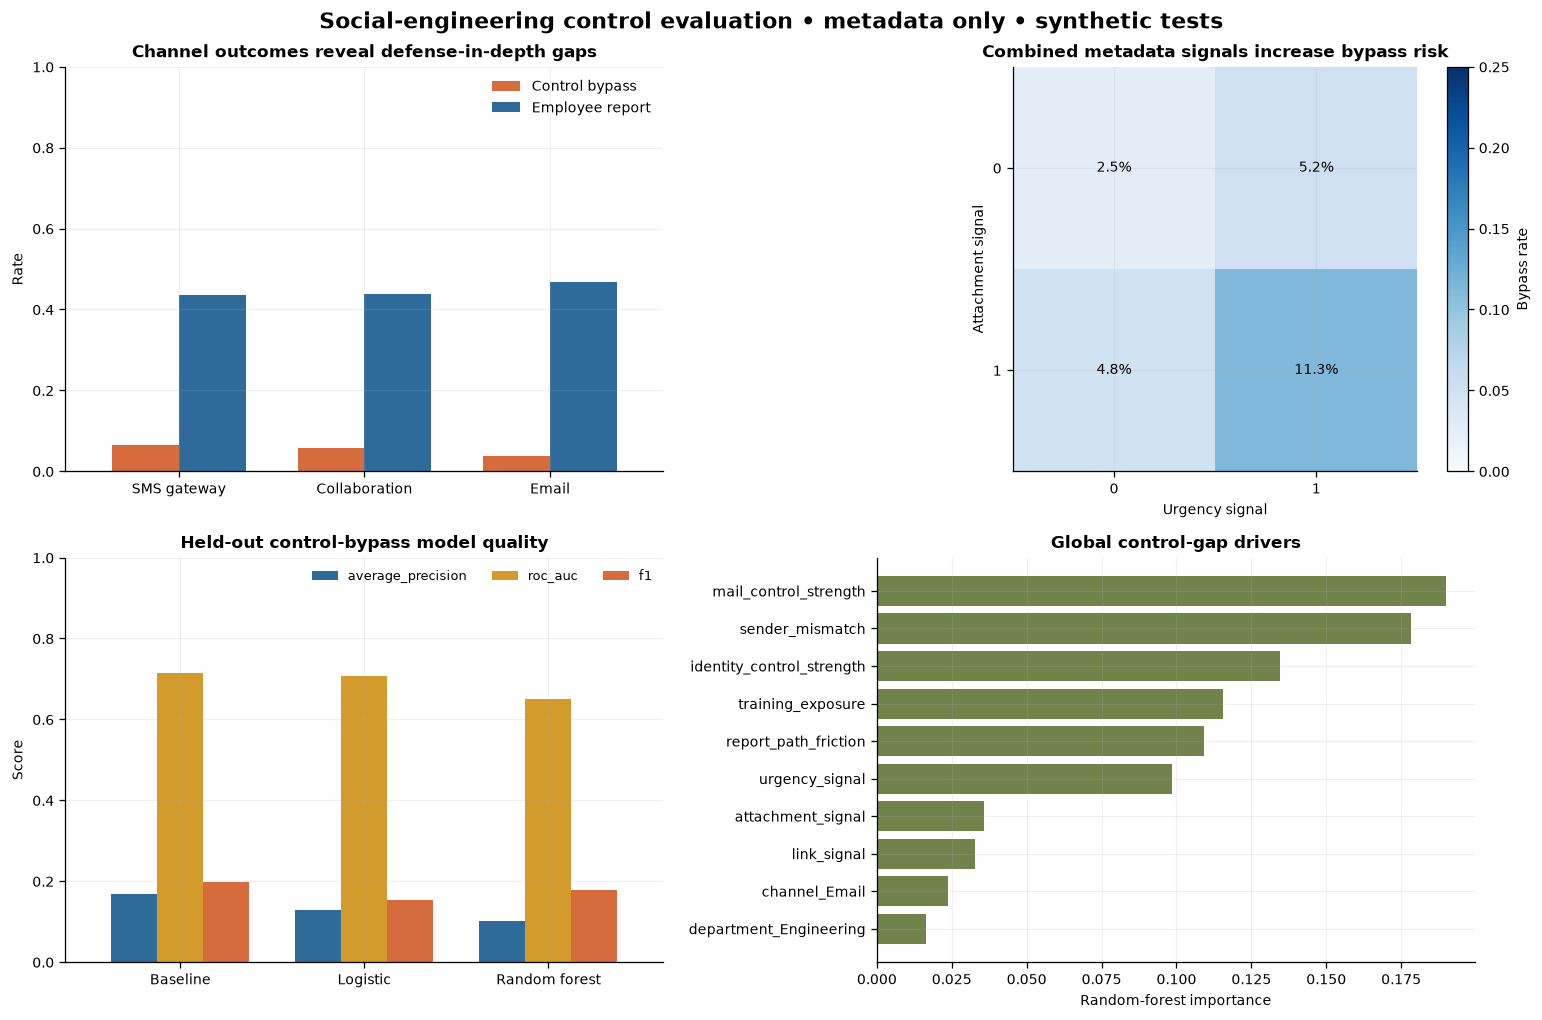

In [4]:
feature_columns = [
    "channel", "department", "urgency_signal", "attachment_signal", "link_signal",
    "sender_mismatch", "mail_control_strength", "identity_control_strength",
    "training_exposure", "report_path_friction",
]
categorical_features = ["channel", "department"]
numeric_features = [column for column in feature_columns if column not in categorical_features]
train_index, test_index = train_test_split(
    np.arange(len(simulations)), test_size=0.28, random_state=SEED,
    stratify=simulations["control_bypass"],
)
X_train = simulations.loc[train_index, feature_columns]
X_test = simulations.loc[test_index, feature_columns]
y_train = simulations.loc[train_index, "control_bypass"]
y_test = simulations.loc[test_index, "control_bypass"]

logistic = build_pipeline(numeric_features, categorical_features,
                          LogisticRegression(max_iter=1200, class_weight="balanced", random_state=SEED))
forest = build_pipeline(numeric_features, categorical_features,
                        RandomForestClassifier(n_estimators=260, min_samples_leaf=7, class_weight="balanced", random_state=SEED))
logistic.fit(X_train, y_train)
forest.fit(X_train, y_train)
probabilities = {
    "Baseline": simulations.loc[test_index, "control_gap_score"].to_numpy() / 100,
    "Logistic": logistic.predict_proba(X_test)[:, 1],
    "Random forest": forest.predict_proba(X_test)[:, 1],
}
metrics_table = pd.DataFrame([
    {"model": name, **model_metrics(y_test, values, 0.5)}
    for name, values in probabilities.items()
]).set_index("model")
importance = feature_importance_table(forest).head(10).sort_values("importance")

signal_matrix = simulations.pivot_table(
    index="attachment_signal", columns="urgency_signal", values="control_bypass", aggfunc="mean"
)
fig, axes = plt.subplots(2, 2, figsize=(13.5, 9.0))
control_summary[["bypass_rate", "report_rate"]].plot(
    kind="bar", ax=axes[0, 0], color=[ORANGE, BLUE], width=0.72
)
axes[0, 0].set(title="Channel outcomes reveal defense-in-depth gaps", xlabel="", ylabel="Rate", ylim=(0, 1))
axes[0, 0].tick_params(axis="x", rotation=0)
axes[0, 0].legend(["Control bypass", "Employee report"], frameon=False)

image = axes[0, 1].imshow(signal_matrix.values, cmap="Blues", vmin=0, vmax=max(0.25, signal_matrix.values.max()))
axes[0, 1].set(title="Combined metadata signals increase bypass risk", xlabel="Urgency signal", ylabel="Attachment signal",
               xticks=[0, 1], yticks=[0, 1])
for row in range(2):
    for column in range(2):
        axes[0, 1].text(column, row, f"{signal_matrix.iloc[row, column]:.1%}", ha="center", va="center", color="black")
fig.colorbar(image, ax=axes[0, 1], fraction=0.046, label="Bypass rate")

metrics_table[["average_precision", "roc_auc", "f1"]].plot(
    kind="bar", ax=axes[1, 0], color=[BLUE, GOLD, ORANGE], width=0.75
)
axes[1, 0].set(title="Held-out control-bypass model quality", xlabel="", ylabel="Score", ylim=(0, 1))
axes[1, 0].tick_params(axis="x", rotation=0)
axes[1, 0].legend(frameon=False, ncol=3, fontsize=8)

axes[1, 1].barh(importance["feature"].str.replace("numeric__", "").str.replace("categorical__", ""),
                importance["importance"], color=OLIVE)
axes[1, 1].set(title="Global control-gap drivers", xlabel="Random-forest importance")
fig.suptitle("Social-engineering control evaluation • metadata only • synthetic tests", fontsize=14, fontweight="bold")
fig.tight_layout()

print(metrics_table.round(3).to_string())
print("\nDecision insight: improve the weakest channel while preserving a low-friction employee reporting path.")


## Checks

Assertions verify data grain, bounds, holdout integrity, and defense-in-depth outcome logic.


In [5]:
assert simulations["simulation_id"].is_unique
assert simulations.isna().sum().sum() == 0
assert simulations[["control_bypass", "employee_reported", "layered_success"]].isin([0, 1]).all().all()
assert set(train_index).isdisjoint(set(test_index))
assert metrics_table[["average_precision", "roc_auc", "precision", "recall", "f1"]].apply(lambda column: column.between(0, 1).all()).all()
assert (simulations.loc[simulations["control_bypass"].eq(0), "layered_success"] == 1).all()
print("All checks passed: unique tests, complete metadata, bounded outcomes, clean holdout, and valid layered-control logic.")


All checks passed: unique tests, complete metadata, bounded outcomes, clean holdout, and valid layered-control logic.


## Next Steps

- Obtain written authorization, HR/legal review, audience protections, and a no-blame learning objective before any real simulation.
- Measure control detection, safe-reporting behavior, and time-to-triage separately; do not rank or shame individuals.
- Add uncertainty intervals and minimum sample sizes before comparing departments or channels.
- Feed confirmed control gaps into detection engineering, mail-policy hardening, and accessible reporting improvements.
